In [1]:
import torch
import cv2
import numpy as np
import matplotlib.pyplot as plt
import supervision as sv
from PIL import Image

from transformers import AutoProcessor, AutoModelForZeroShotObjectDetection
from transformers import BlipProcessor, BlipForConditionalGeneration
from segment_anything import sam_model_registry, SamPredictor

DEVICE = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
IMAGE_PATH = "../data/raw_images/img_11.jpg"

# Image captioning with BLIP 

In [2]:
# Initialize BLIP model 
blip_id = "Salesforce/blip-image-captioning-base"
blip_processor = BlipProcessor.from_pretrained(blip_id)
blip_model = BlipForConditionalGeneration.from_pretrained(blip_id).to(DEVICE)

image_pil = Image.open(IMAGE_PATH).convert('RGB')

# Generate the caption
inputs = blip_processor(image_pil, return_tensors="pt").to(DEVICE)
out = blip_model.generate(**inputs, max_new_tokens=50)
caption = blip_processor.decode(out[0], skip_special_tokens=True)

print(f"--- CAPTION GENERATED BY BLIP ---\n{caption}\n")

# We append a period to help DINO parse the sentence correctly.
text_labels = caption + "."

Loading weights:   0%|          | 0/473 [00:00<?, ?it/s]

--- CAPTION GENERATED BY BLIP ---
a painting of a man and woman in a wooded setting



# Object detection with Grounding DINO

In [3]:
# Initialize Grounding DINO model and processor
dino_id = "IDEA-Research/grounding-dino-base"
dino_processor = AutoProcessor.from_pretrained(dino_id)
dino_model = AutoModelForZeroShotObjectDetection.from_pretrained(dino_id).to(DEVICE)

inputs = dino_processor(images=image_pil, text=text_labels, return_tensors="pt").to(DEVICE)

with torch.no_grad():
    outputs = dino_model(**inputs)

results = dino_processor.post_process_grounded_object_detection(
    outputs, 
    threshold=0.25, 
    target_sizes=[image_pil.size[::-1]], 
    text_labels=[text_labels]
)[0]

boxes_array = results["boxes"].cpu().numpy()
conf_array = results["scores"].cpu().numpy()
labels_text = results["text_labels"]

print(f"Extracted {len(boxes_array)} bounding boxes from DINO.")

Loading weights:   0%|          | 0/1182 [00:00<?, ?it/s]

Extracted 4 bounding boxes from DINO.


# Segmentation with SAM Predictor 

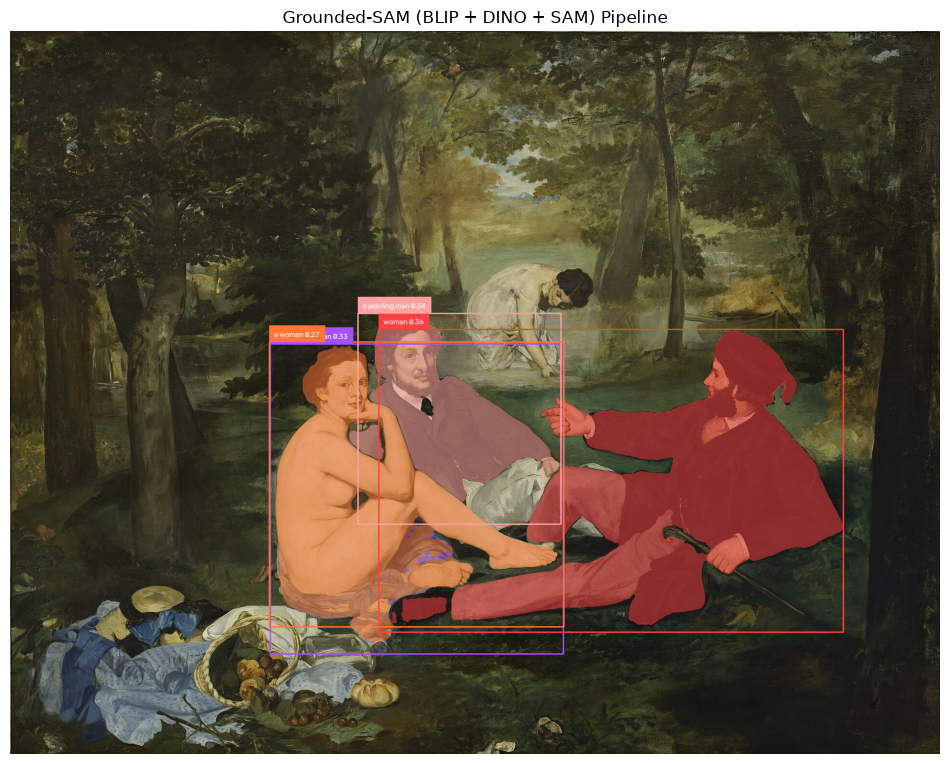

In [ ]:
image_cv2_rgb = np.array(image_pil)

sam = sam_model_registry["vit_h"](checkpoint="../weights/sam_vit_h_4b8939.pth").to(DEVICE)
sam_predictor = SamPredictor(sam)
sam_predictor.set_image(image_cv2_rgb)

# Transform bounding boxes to SAM's expected tensor format
input_boxes = torch.tensor(boxes_array, device=DEVICE)
transformed_boxes = sam_predictor.transform.apply_boxes_torch(input_boxes, image_cv2_rgb.shape[:2])

masks, _, _ = sam_predictor.predict_torch(
    point_coords=None,
    point_labels=None,
    boxes=transformed_boxes,
    multimask_output=False
)
masks_array = masks.squeeze(1).cpu().numpy()

# Format data for Supervision
detections = sv.Detections(
    xyxy=boxes_array,
    confidence=conf_array,
    class_id=np.arange(len(labels_text)),
    mask=masks_array
)

custom_labels = [f"{label} {conf:.2f}" for label, conf in zip(labels_text, conf_array)]

mask_annotator = sv.MaskAnnotator()
box_annotator = sv.BoxAnnotator()
label_annotator = sv.LabelAnnotator()

image_cv2_bgr = cv2.cvtColor(image_cv2_rgb, cv2.COLOR_RGB2BGR)
annotated_image = mask_annotator.annotate(scene=image_cv2_bgr.copy(), detections=detections)
annotated_image = box_annotator.annotate(scene=annotated_image, detections=detections)
annotated_image = label_annotator.annotate(scene=annotated_image, detections=detections, labels=custom_labels)

plt.figure(figsize=(12, 10))
plt.imshow(cv2.cvtColor(annotated_image, cv2.COLOR_BGR2RGB))
plt.title("Grounded-SAM (BLIP + DINO + SAM) Pipeline")
plt.axis('off')
plt.show()